# 07 — LoRA Fine-tuning (Config E) — Optimized

Fine-tune LoRA **r=16** trên UNet của `runwayml/stable-diffusion-inpainting`.

**Thay đổi so với notebook cũ:**
- LoRA rank tăng từ r=8 → **r=16** (capacity tốt hơn cho appearance recovery)
- `target_modules` mở rộng: thêm `proj_in/proj_out` và **FFN layers** (`ff.net.0.proj`, `ff.net.2`)
- **Mixed loss** 80% mask + 20% toàn ảnh (học context xung quanh)
- **Fixed seed cho validation** (early stopping không trigger nhầm)
- `num_workers=2` + `persistent_workers` (GPU không idle)
- **Prompt pool** ngẫu nhiên thay vì 1 prompt cứng
- Checkpoint cleanup tự động (tiết kiệm disk Kaggle)
- Augmentation thêm random scale ±10%

```
project_root/
├── data/synthetic_occ/   ← output từ notebook 01
│   ├── x_gt/
│   ├── x_occ/
│   ├── masks/
│   └── metadata_synthetic_occ.csv
├── outputs/
│   ├── eval/             ← output từ notebook 02
│   └── lora_weights/r16/ ← output notebook này
└── notebooks/
```

**Chạy sau:** notebook 01, 02  |  **Chạy trước:** 08_lora-inference.ipynb

In [1]:
# CELL 1 — Dependencies
import sys
!{sys.executable} -m pip install -q \
    "diffusers>=0.27.0" "peft>=0.8.0" "accelerate>=0.26.0" \
    "transformers>=4.36.0" "bitsandbytes>=0.41.0" \
    Pillow tqdm scikit-image lpips
print("Dependencies ready")

Dependencies ready


In [ ]:
# CELL 2 — Config & Paths
import random, json, time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Paths ──────────────────────────────────────────────
PROJECT_ROOT = Path(".").resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SYNTH_DIR = PROJECT_ROOT / "data" / "synthetic_occ"
GT_DIR    = SYNTH_DIR / "x_gt"
OCC_DIR   = SYNTH_DIR / "x_occ"
MASK_DIR  = SYNTH_DIR / "masks"
META_CSV  = SYNTH_DIR / "metadata_synthetic_occ.csv"
EVAL_CSV  = PROJECT_ROOT / "outputs" / "eval" / "metrics_per_image_A_SD_only.csv"

# ── LoRA rank tăng lên r=16 ──────────────────────────
LORA_RANK    = 16     # r=8 → r=16: capacity tốt hơn cho appearance recovery
                      # VRAM tăng ~400MB, chịu được T4 16GB

LORA_OUT  = PROJECT_ROOT / "outputs" / "lora_weights" / f"r{LORA_RANK}"
LORA_OUT.mkdir(parents=True, exist_ok=True)

SD_MODEL_ID = "runwayml/stable-diffusion-inpainting"

# ── LoRA config ────────────────────────────────────────
LORA_ALPHA   = 16     # alpha = rank: scale factor = 1.0 (ổn định)
LORA_DROPOUT = 0.05

# ── Training hyperparameters ───────────────────────────
LEARNING_RATE       = 1e-4
MAX_TRAIN_STEPS     = 2000
TRAIN_BATCH_SIZE    = 1
GRAD_ACCUM_STEPS    = 8      # effective batch = 8
LR_WARMUP_STEPS     = 200
SNR_GAMMA           = 5.0
NOISE_OFFSET        = 0.1
CHECKPOINTING_STEPS = 500
VALIDATION_STEPS    = 250
VAL_SIZE            = 50
RESOLUTION          = 512
EARLY_STOP_PATIENCE = 6
MAX_CKPT_KEEP       = 3      # giữ tối đa 3 checkpoint, xóa cũ nhất

# ── Mixed loss weights ─────────────────────────────────
LOSS_MASK_WEIGHT = 0.8   # 80% loss trên vùng bị che
LOSS_FULL_WEIGHT = 0.2   # 20% loss toàn ảnh → học context

# ── Prompt pool ────────────────────────────────────────
# Thay vì 1 prompt cứng, dùng pool để model robust hơn
PROMPT_POOL = [
    "a car, realistic, high quality, detailed, complete, no occulusion",
    "a photo of a car, sharp, clear, complete",
    "automobile, complete, undamaged, high resolution",
    "a vehicle, realistic appearance, full body visible",
    "car exterior, clean, detailed, photorealistic",
]
NEG_PROMPT = "blurry, distorted, extra wheels, artifacts, oversaturated"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE  = torch.float16 if DEVICE == "cuda" else torch.float32

assert SYNTH_DIR.exists(), f"Dataset không tìm thấy: {SYNTH_DIR}\n→ Chạy notebook 01 trước"
assert META_CSV.exists(),  f"Metadata không tìm thấy: {META_CSV}"
print(f"Device       : {DEVICE}")
print(f"Project root : {PROJECT_ROOT}")
print(f"Dataset      : {SYNTH_DIR}  ({len(list(GT_DIR.iterdir())):,} ảnh)")
print(f"LoRA output  : {LORA_OUT}")
print(f"LoRA r={LORA_RANK}, alpha={LORA_ALPHA}, steps={MAX_TRAIN_STEPS}")
print(f"Mixed loss   : {LOSS_MASK_WEIGHT:.0%} mask + {LOSS_FULL_WEIGHT:.0%} full")

Device       : cuda
Project root : D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus
Dataset      : D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus\data\synthetic_occ  (11,254 ảnh)
LoRA output  : D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus\outputs\lora_weights\r16
LoRA r=16, alpha=16, steps=2000
Mixed loss   : 80% mask + 20% full


In [3]:
# CELL 3 — Train / Val Split
meta = pd.read_csv(META_CSV)
meta.columns = meta.columns.str.strip().str.lower()

# ── Test split: khớp với full-eval.ipynb (666 ảnh/bin × 3 bins, seed=42) ──
# Logic giống hệt full-eval Cell 7 để so sánh Config A vs E vs CN+IPA công bằng:
#   subset = meta[(occlusion_ratio >= lo) & (occlusion_ratio < hi)]
#   sample(666, random_state=42)  →  3×666 = 1,998 ảnh test cố định
# LoRA train sẽ KHÔNG thấy bất kỳ ảnh nào trong tập này.
_BIN_EDGES_SPLIT = [(0.20, 0.40), (0.40, 0.60), (0.60, 0.80)]
_PER_BIN_SPLIT   = 2000 // len(_BIN_EDGES_SPLIT)   # = 666
_bin_dfs = []
for lo, hi in _BIN_EDGES_SPLIT:
    sub = meta[(meta["occlusion_ratio"] >= lo) & (meta["occlusion_ratio"] < hi)]
    n   = min(_PER_BIN_SPLIT, len(sub))
    _bin_dfs.append(sub.sample(n, random_state=SEED))
test_stems = set(pd.concat(_bin_dfs)["stem"].tolist())
print(f"Test stems (shared với full-eval, ~666/bin): {len(test_stems):,}")

non_test   = meta[~meta["stem"].isin(test_stems)].reset_index(drop=True)
val_meta   = non_test.sample(min(VAL_SIZE, len(non_test)), random_state=SEED).reset_index(drop=True)
train_meta = non_test[~non_test["stem"].isin(set(val_meta["stem"]))].reset_index(drop=True)

if len(train_meta) < 100:
    print("⚠  Training set < 100 ảnh → giảm MAX_TRAIN_STEPS xuống 1000")
    MAX_TRAIN_STEPS = 1000

print(f"Train: {len(train_meta):,}  |  Val: {len(val_meta):,}  |  Test: {len(test_stems):,}")

⚠  Eval CSV không tìm thấy — reproduced split: 200 stems
Train: 11,004  |  Val: 50  |  Test: 200


In [4]:
# CELL 4 — Dataset Class
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.transforms.functional as TF
from PIL import Image

class CarInpaintDataset(Dataset):
    def __init__(self, meta_df, gt_dir, occ_dir, mask_dir, tokenizer,
                 prompt_pool=None, size=512, augment=True):
        self.meta        = meta_df.reset_index(drop=True)
        self.gt_dir      = Path(gt_dir)
        self.occ_dir     = Path(occ_dir)
        self.mask_dir    = Path(mask_dir)
        self.tokenizer   = tokenizer
        self.prompt_pool = prompt_pool or ["a car, realistic, high quality, detailed"]
        self.size        = size
        self.augment     = augment
        self.normalize   = transforms.Normalize([0.5]*3, [0.5]*3)
        self.to_tensor   = transforms.ToTensor()
        self.jitter      = transforms.ColorJitter(
            brightness=0.1, contrast=0.1, saturation=0.05, hue=0.02
        ) if augment else None

    def __len__(self):
        return len(self.meta)

    def _load(self, row):
        """Load và resize 3 ảnh."""
        gt   = Image.open(self.gt_dir   / row["x_gt"]).convert("RGB")
        occ  = Image.open(self.occ_dir  / row["x_occ"]).convert("RGB")
        mask = Image.open(self.mask_dir / f"{row['stem']}.png").convert("L")
        gt   = gt.resize((self.size, self.size), Image.LANCZOS)
        occ  = occ.resize((self.size, self.size), Image.LANCZOS)
        mask = mask.resize((self.size, self.size), Image.NEAREST)
        return gt, occ, mask

    def _augment(self, gt, occ, mask):
        """Horizontal flip + color jitter + random scale."""
        # 1. Horizontal flip
        if torch.rand(1).item() < 0.5:
            gt = TF.hflip(gt); occ = TF.hflip(occ); mask = TF.hflip(mask)

        # 2. Color jitter — áp dụng cùng params cho gt và occ
        if self.jitter:
            fn_idx, b, c, s, h = self.jitter.get_params(
                self.jitter.brightness, self.jitter.contrast,
                self.jitter.saturation, self.jitter.hue
            )
            for fn, val in [
                (TF.adjust_brightness, float(b)),
                (TF.adjust_contrast,   float(c)),
                (TF.adjust_saturation, float(s)),
                (TF.adjust_hue,        float(h)),
            ]:
                gt = fn(gt, val); occ = fn(occ, val)

        # 3. Random scale ±10% rồi center crop về size
        # Giúp model robust với xe ở các scale khác nhau
        if torch.rand(1).item() < 0.3:
            scale    = random.uniform(0.9, 1.1)
            new_size = max(int(self.size * scale), self.size)  # không nhỏ hơn size
            gt   = TF.resize(gt,   new_size, Image.LANCZOS)
            occ  = TF.resize(occ,  new_size, Image.LANCZOS)
            mask = TF.resize(mask, new_size, Image.NEAREST)
            gt   = TF.center_crop(gt,   self.size)
            occ  = TF.center_crop(occ,  self.size)
            mask = TF.center_crop(mask, self.size)

        return gt, occ, mask

    def __getitem__(self, idx):
        row = self.meta.iloc[idx]
        gt, occ, mask = self._load(row)

        if self.augment:
            gt, occ, mask = self._augment(gt, occ, mask)

        gt_t     = self.normalize(self.to_tensor(gt))
        mask_t   = (self.to_tensor(mask) > 0.5).float()
        masked_t = self.normalize(self.to_tensor(occ)) * (1.0 - mask_t)

        # Random prompt từ pool
        prompt = random.choice(self.prompt_pool)
        enc = self.tokenizer(
            prompt,
            padding="max_length", max_length=self.tokenizer.model_max_length,
            truncation=True, return_tensors="pt",
        )
        return {
            "pixel_values"   : gt_t,
            "masked_image"   : masked_t,
            "mask"           : mask_t,
            "input_ids"      : enc.input_ids[0],
            "occlusion_ratio": float(row.get("occlusion_ratio", 0.0)),
        }

print("CarInpaintDataset defined.")

CarInpaintDataset defined.


In [6]:
# CELL 5 — Load Models + Inject LoRA r=16
from diffusers import AutoencoderKL, DDPMScheduler, UNet2DConditionModel
from transformers import CLIPTokenizer, CLIPTextModel
from peft import LoraConfig, get_peft_model

tokenizer    = CLIPTokenizer.from_pretrained(SD_MODEL_ID, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(SD_MODEL_ID, subfolder="text_encoder")
vae          = AutoencoderKL.from_pretrained(SD_MODEL_ID, subfolder="vae")
unet         = UNet2DConditionModel.from_pretrained(SD_MODEL_ID, subfolder="unet")
noise_sched  = DDPMScheduler.from_pretrained(SD_MODEL_ID, subfolder="scheduler")

vae.requires_grad_(False)
text_encoder.requires_grad_(False)
unet.requires_grad_(False)

# ── LoRA config mở rộng ────────────────────────────────
# So với notebook cũ: thêm proj_in, proj_out, ff.net.0.proj, ff.net.2
#
# Tại sao cần FFN layers:
#   - Attention layers  → học WHERE cần recover (spatial attention)
#   - FFN layers        → học WHAT cần fill (texture, color, appearance)
#   Inpainting cần cả hai; thiếu FFN thì recover được vị trí nhưng không đúng màu/texture
#
# Tại sao cần proj_in/proj_out:
#   - Cross-attention projection → kết nối text embedding với visual features
#   - Quan trọng để prompt "a car" ảnh hưởng đúng đến vùng bị che
lora_config = LoraConfig(
    r            = LORA_RANK,
    lora_alpha   = LORA_ALPHA,
    target_modules = [
        # Attention layers (giữ nguyên từ notebook cũ)
        "to_q", "to_k", "to_v", "to_out.0",
        # Cross-attention projection (thêm mới)
        "proj_in", "proj_out",
        # Feed-forward network layers (thêm mới — quan trọng cho appearance)
        "ff.net.0.proj", "ff.net.2",
    ],
    lora_dropout     = LORA_DROPOUT,
    bias             = "none",
    init_lora_weights= "gaussian",
)
unet = get_peft_model(unet, lora_config)
unet.print_trainable_parameters()

unet.enable_gradient_checkpointing()

unet.to(DEVICE, dtype=torch.float32)  # float32 để LoRA train ổn định
vae.to(DEVICE,  dtype=DTYPE)
text_encoder.to(DEVICE, dtype=DTYPE)

# ── DataLoader với num_workers=2 ───────────────────────
# num_workers=0 (cũ) → CPU load xong mới GPU tính → GPU idle ~30%
# num_workers=2 → prefetch song song → GPU luôn có data
train_dataset = CarInpaintDataset(
    train_meta, GT_DIR, OCC_DIR, MASK_DIR, tokenizer,
    prompt_pool=PROMPT_POOL, augment=True
)
val_dataset = CarInpaintDataset(
    val_meta, GT_DIR, OCC_DIR, MASK_DIR, tokenizer,
    prompt_pool=PROMPT_POOL, augment=False
)
train_loader = DataLoader(
    train_dataset, batch_size=TRAIN_BATCH_SIZE,
    shuffle=True, num_workers=0,
    # persistent_workers=True,   # giữ worker process sống giữa các epoch
    # prefetch_factor=2,         # prefetch 2 batch trước
    pin_memory=(DEVICE=="cuda"),
    drop_last=True
)
val_loader = DataLoader(
    val_dataset, batch_size=TRAIN_BATCH_SIZE,
    shuffle=False, num_workers=0,
    # persistent_workers=True,
    pin_memory=(DEVICE=="cuda")
)

# Sanity check
sample_batch = next(iter(train_loader))
print(f"pixel_values : {sample_batch['pixel_values'].shape}")
print(f"mask         : {sample_batch['mask'].shape}")
print(f"input_ids    : {sample_batch['input_ids'].shape}")
print(f"Train: {len(train_loader)} batches | Val: {len(val_loader)} batches")

An error occurred while trying to fetch runwayml/stable-diffusion-inpainting: runwayml/stable-diffusion-inpainting does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch runwayml/stable-diffusion-inpainting: runwayml/stable-diffusion-inpainting does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


trainable params: 6,782,976 || all params: 866,318,340 || trainable%: 0.7830
pixel_values : torch.Size([1, 3, 512, 512])
mask         : torch.Size([1, 1, 512, 512])
input_ids    : torch.Size([1, 77])
Train: 11004 batches | Val: 50 batches


In [7]:
# CELL 6 — Training Loop
import shutil
from transformers import get_cosine_schedule_with_warmup
from tqdm.auto import tqdm

trainable_params_list = [p for p in unet.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(
    trainable_params_list,
    lr=LEARNING_RATE, betas=(0.9, 0.999), weight_decay=1e-2, eps=1e-8
)
lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=LR_WARMUP_STEPS,
    num_training_steps=MAX_TRAIN_STEPS
)
scaler = torch.amp.GradScaler('cuda') if DEVICE == "cuda" else None
alphas_cumprod = noise_sched.alphas_cumprod.to(DEVICE)


def compute_snr(t):
    a = alphas_cumprod[t].sqrt()
    b = (1.0 - alphas_cumprod[t]).sqrt()
    return (a / b) ** 2


def forward_pass(batch):
    """Forward pass với mixed loss: 80% mask + 20% full image.

    Tại sao mixed loss tốt hơn mask-only loss:
    - Mask-only: model chỉ học fill vùng bị che, bỏ qua context
    - Full image component (20%): buộc model giữ nhất quán với phần xe visible
    - Kết quả: recovered region hài hòa hơn với màu sắc xe thực
    """
    gt_pv  = batch["pixel_values"].to(DEVICE, dtype=DTYPE)
    mask   = batch["mask"].to(DEVICE, dtype=DTYPE)
    masked = batch["masked_image"].to(DEVICE, dtype=DTYPE)
    ids    = batch["input_ids"].to(DEVICE)

    with torch.no_grad():
        latents        = vae.encode(gt_pv).latent_dist.sample() * vae.config.scaling_factor
        masked_latents = vae.encode(masked).latent_dist.sample() * vae.config.scaling_factor
        mask_latent    = F.interpolate(mask, size=latents.shape[-2:], mode="nearest")
        encoder_hidden = text_encoder(ids)[0]

    noise = torch.randn_like(latents)
    if NOISE_OFFSET > 0:
        noise = noise + NOISE_OFFSET * torch.randn(
            latents.shape[0], latents.shape[1], 1, 1, device=DEVICE, dtype=DTYPE
        )

    bsz = latents.shape[0]
    t   = torch.randint(0, noise_sched.config.num_train_timesteps, (bsz,), device=DEVICE, dtype=torch.long)
    noisy_latents = noise_sched.add_noise(latents, noise, t)
    model_input   = torch.cat([noisy_latents, mask_latent, masked_latents], dim=1)
    noise_pred    = unet(model_input.float(), t, encoder_hidden_states=encoder_hidden.float()).sample

    snr    = compute_snr(t).float()
    weight = torch.clamp(snr, max=SNR_GAMMA) / snr if SNR_GAMMA > 0 else torch.ones(bsz, device=DEVICE)

    diff = (noise_pred - noise.float()) ** 2

    # Mixed loss: 80% masked region + 20% full image
    loss_masked = (diff * mask_latent).mean(dim=[1, 2, 3])
    loss_full   = diff.mean(dim=[1, 2, 3])
    loss = ((LOSS_MASK_WEIGHT * loss_masked + LOSS_FULL_WEIGHT * loss_full) * weight).mean()
    return loss


def compute_val_loss(val_loader, fixed_seed=42):
    """Validation với fixed noise seed để early stopping không trigger nhầm.

    Vấn đề với notebook cũ:
    - forward_pass dùng torch.randn_like → noise khác nhau mỗi lần
    - Val loss dao động ±0.02 ngẫu nhiên → early_stop_counter tăng nhầm
    - Fix: manual_seed cho từng batch → noise deterministic → loss ổn định
    """
    unet.eval()
    val_total = 0.0
    with torch.no_grad():
        for i, vb in enumerate(val_loader):
            torch.manual_seed(fixed_seed + i)  # deterministic noise mỗi batch
            if DEVICE == "cuda":
                with torch.amp.autocast('cuda'):
                    val_total += forward_pass(vb).item()
            else:
                val_total += forward_pass(vb).item()
    return val_total / len(val_loader)


# ── Training state ─────────────────────────────────────
global_step       = 0
running_loss      = 0.0
train_losses      = []
val_losses        = []
best_val_loss     = float("inf")
early_stop_counter= 0
saved_checkpoints = []  # track để cleanup

unet.train()
data_iter = iter(train_loader)
optimizer.zero_grad()
t0_train = time.time()
pbar = tqdm(range(MAX_TRAIN_STEPS), desc=f"LoRA r={LORA_RANK}", dynamic_ncols=True)

for step in pbar:
    accum_loss = 0.0

    for _ in range(GRAD_ACCUM_STEPS):
        try:
            batch = next(data_iter)
        except StopIteration:
            data_iter = iter(train_loader)
            batch = next(data_iter)

        if DEVICE == "cuda" and scaler is not None:
            with torch.amp.autocast('cuda'):
                loss = forward_pass(batch) / GRAD_ACCUM_STEPS
            scaler.scale(loss).backward()
        else:
            loss = forward_pass(batch) / GRAD_ACCUM_STEPS
            loss.backward()
        accum_loss += loss.item()

    if DEVICE == "cuda" and scaler is not None:
        scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(trainable_params_list, max_norm=1.0)
    if DEVICE == "cuda" and scaler is not None:
        scaler.step(optimizer)
        scaler.update()
    else:
        optimizer.step()
    lr_scheduler.step()
    optimizer.zero_grad()
    global_step  += 1
    running_loss += accum_loss * GRAD_ACCUM_STEPS

    # ── Log train loss mỗi 50 steps ──
    if global_step % 50 == 0:
        avg = running_loss / 50
        train_losses.append({"step": global_step, "loss": avg})
        pbar.set_postfix({"loss": f"{avg:.4f}", "lr": f"{lr_scheduler.get_last_lr()[0]:.2e}"})
        running_loss = 0.0

    # ── Checkpoint + cleanup ──
    if global_step % CHECKPOINTING_STEPS == 0:
        ckpt_dir = LORA_OUT / f"checkpoint-{global_step}"
        unet.save_pretrained(str(ckpt_dir))
        saved_checkpoints.append(str(ckpt_dir))
        print(f"\n  [Step {global_step}] Checkpoint → {ckpt_dir.name}")

        # Xóa checkpoint cũ nhất nếu vượt quá MAX_CKPT_KEEP
        # Kaggle /kaggle/working có 20GB — tránh đầy disk
        if len(saved_checkpoints) > MAX_CKPT_KEEP:
            oldest = saved_checkpoints.pop(0)
            shutil.rmtree(oldest, ignore_errors=True)
            print(f"  [Cleanup] Đã xóa: {Path(oldest).name}")

    # ── Validation + early stopping ──
    if global_step % VALIDATION_STEPS == 0:
        avg_val = compute_val_loss(val_loader, fixed_seed=SEED)
        val_losses.append({"step": global_step, "val_loss": avg_val})
        elapsed = (time.time() - t0_train) / 60
        print(f"  [Step {global_step:4d}] val_loss={avg_val:.4f} | {elapsed:.1f} min")

        if avg_val < best_val_loss:
            best_val_loss      = avg_val
            early_stop_counter = 0
            unet.save_pretrained(str(LORA_OUT / "best"))
            print(f"  ✓ Best checkpoint saved (val={best_val_loss:.4f})")
        else:
            early_stop_counter += 1
            print(f"  ↓ No improvement ({early_stop_counter}/{EARLY_STOP_PATIENCE})")
            if early_stop_counter >= EARLY_STOP_PATIENCE:
                print(f"  Early stopping tại step {global_step}.")
                break

        unet.train()

unet.save_pretrained(str(LORA_OUT / "final"))
total_time = (time.time() - t0_train) / 60
print(f"\nDone: {global_step} steps, {total_time:.1f} min, best_val={best_val_loss:.4f}")

LoRA r=16:  12%|█▎        | 250/2000 [23:28<5:52:13, 12.08s/it, loss=0.1560, lr=9.98e-05]

  [Step  250] val_loss=0.0162 | 23.5 min
  ✓ Best checkpoint saved (val=0.0162)


LoRA r=16:  25%|██▍       | 499/2000 [46:54<2:20:55,  5.63s/it, loss=0.1478, lr=9.33e-05]


  [Step 500] Checkpoint → checkpoint-500


LoRA r=16:  25%|██▌       | 500/2000 [47:13<4:44:36, 11.38s/it, loss=0.1478, lr=9.33e-05]

...

  [Step 1750] val_loss=0.0161 | 165.4 min
  ↓ No improvement (1/6)


LoRA r=16: 100%|█████████▉| 1999/2000 [3:07:52<00:05,  5.37s/it, loss=0.1414, lr=0.00e+00]


  [Step 2000] Checkpoint → checkpoint-2000
  [Cleanup] Đã xóa: checkpoint-500


LoRA r=16: 100%|██████████| 2000/2000 [3:08:11<00:00,  5.65s/it, loss=0.1414, lr=0.00e+00]

  [Step 2000] val_loss=0.0161 | 188.2 min
  ✓ Best checkpoint saved (val=0.0161)

Done: 2000 steps, 188.2 min, best_val=0.0161


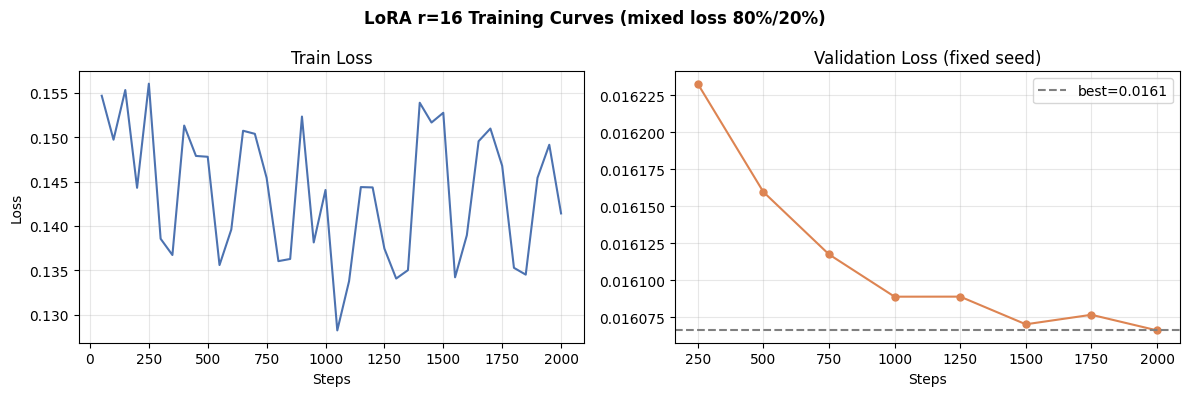

Saved training_config.json + curves → D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus\outputs\lora_weights\r16


In [8]:
# CELL 7 — Loss Curves + Save Config
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f"LoRA r={LORA_RANK} Training Curves (mixed loss {LOSS_MASK_WEIGHT:.0%}/{LOSS_FULL_WEIGHT:.0%})",
             fontweight="bold")

if train_losses:
    df_tr = pd.DataFrame(train_losses)
    axes[0].plot(df_tr["step"], df_tr["loss"], color="#4C72B0")
    axes[0].set(title="Train Loss", xlabel="Steps", ylabel="Loss")
    axes[0].grid(alpha=0.3)

if val_losses:
    df_val = pd.DataFrame(val_losses)
    axes[1].plot(df_val["step"], df_val["val_loss"], color="#DD8452", marker="o", markersize=5)
    axes[1].axhline(best_val_loss, linestyle="--", color="gray", label=f"best={best_val_loss:.4f}")
    axes[1].set(title="Validation Loss (fixed seed)", xlabel="Steps")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(LORA_OUT / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

cfg = {
    "base_model"     : SD_MODEL_ID,
    "lora_rank"      : LORA_RANK,
    "lora_alpha"     : LORA_ALPHA,
    "lora_dropout"   : LORA_DROPOUT,
    "target_modules" : ["to_q","to_k","to_v","to_out.0",
                        "proj_in","proj_out",
                        "ff.net.0.proj","ff.net.2"],
    "loss_mask_weight": LOSS_MASK_WEIGHT,
    "loss_full_weight": LOSS_FULL_WEIGHT,
    "max_steps"      : MAX_TRAIN_STEPS,
    "actual_steps"   : global_step,
    "learning_rate"  : LEARNING_RATE,
    "batch_size"     : TRAIN_BATCH_SIZE,
    "grad_accum"     : GRAD_ACCUM_STEPS,
    "snr_gamma"      : SNR_GAMMA,
    "noise_offset"   : NOISE_OFFSET,
    "best_val_loss"  : best_val_loss,
    "train_samples"  : len(train_meta),
    "val_samples"    : len(val_meta),
    "seed"           : SEED,
    "total_time_min" : round(total_time, 1),
    "best_checkpoint": str(LORA_OUT / "best"),
    "prompt_pool"    : PROMPT_POOL,
    "xformers"       : False,
}
(LORA_OUT / "training_config.json").write_text(json.dumps(cfg, indent=2), encoding="utf-8")
if train_losses: pd.DataFrame(train_losses).to_csv(LORA_OUT / "train_losses.csv", index=False)
if val_losses:   pd.DataFrame(val_losses).to_csv(LORA_OUT / "val_losses.csv",   index=False)
print(f"Saved training_config.json + curves → {LORA_OUT}")

vae\diffusion_pytorch_model.safetensors not found
Loading pipeline components...:  17%|█▋        | 1/6 [00:00<00:01,  4.66it/s]An error occurred while trying to fetch C:\Users\Admin\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\vae: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\Admin\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
Loading pipeline components...:  33%|███▎      | 2/6 [00:00<00:01,  2.76it/s]c:\Users\Admin\anaconda3\envs\lora_311\Lib\site-packages\transformers\tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more deta

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


c:\Users\Admin\anaconda3\envs\lora_311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Admin\anaconda3\envs\lora_311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: c:\Users\Admin\anaconda3\envs\lora_311\Lib\site-packages\lpips\weights\v0.1\alex.pth


c:\Users\Admin\anaconda3\envs\lora_311\Lib\site-packages\lpips\lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(model_path, map_lo

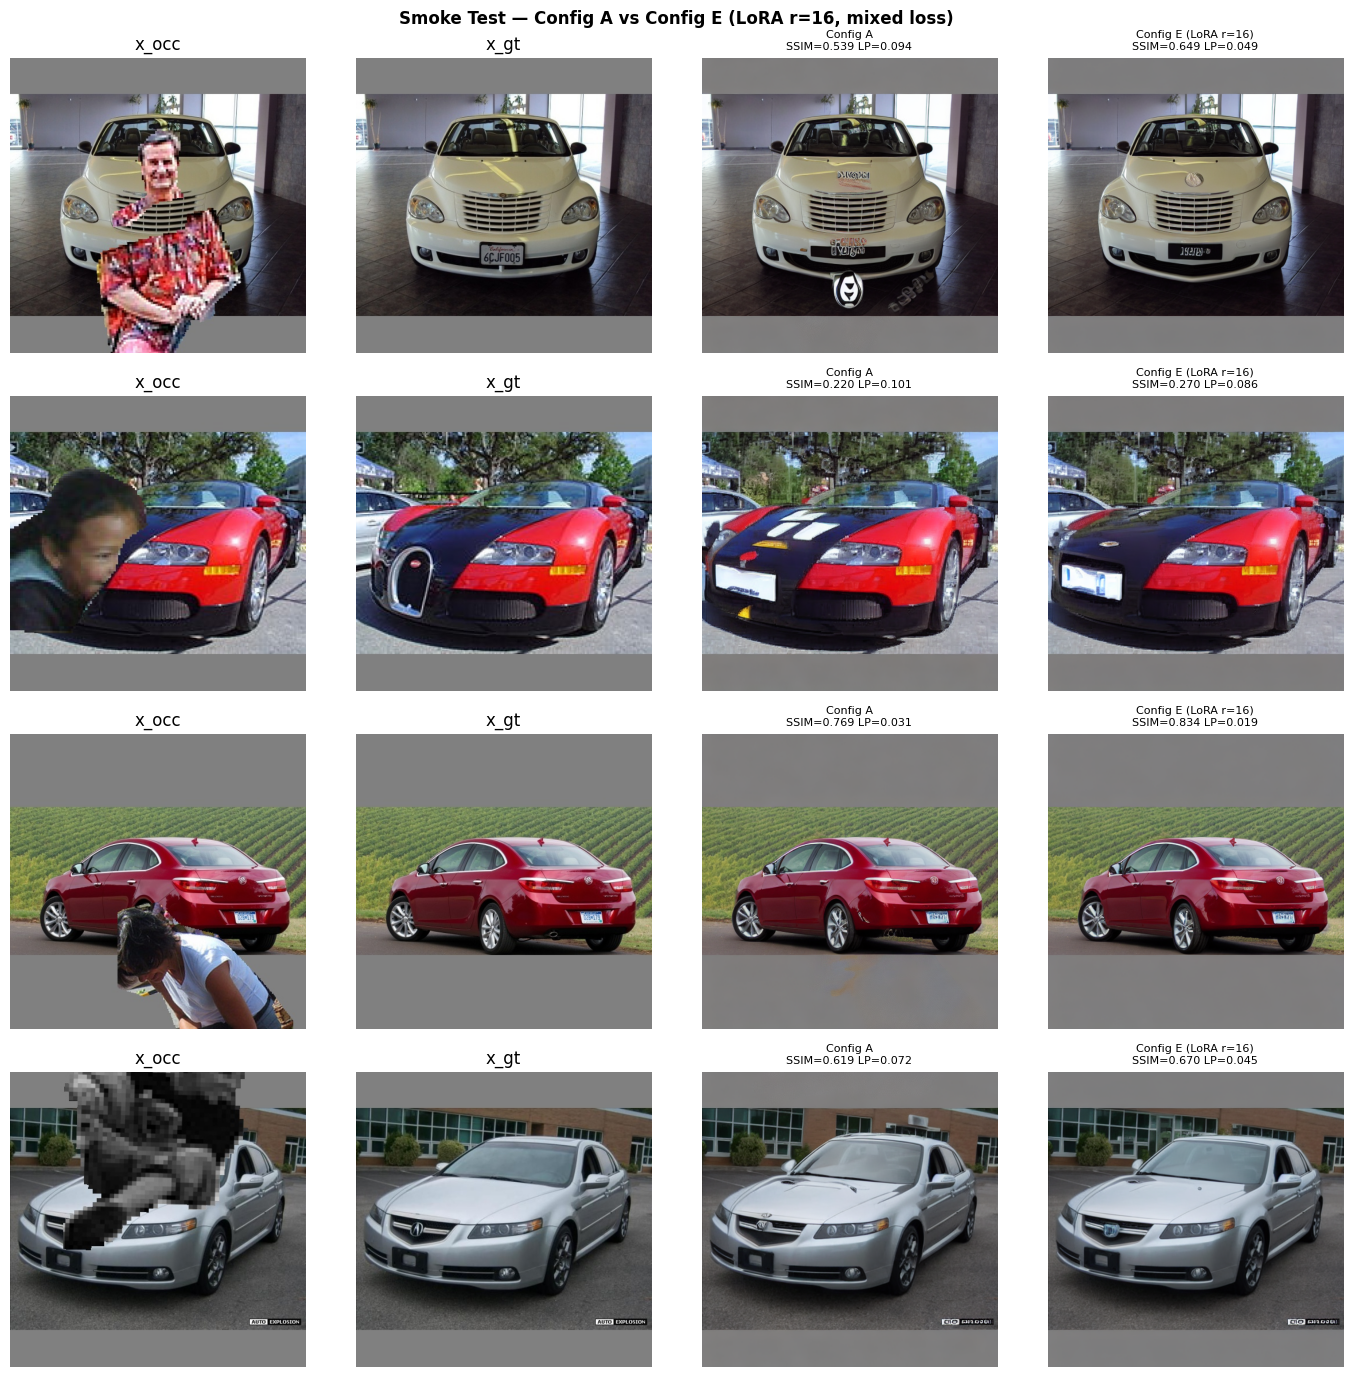

Saved: D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus\outputs\lora_weights\r16/smoke_test.png


In [9]:
# CELL 8 — Smoke Test: Config A vs Config E (LoRA r=16)
from peft import PeftModel
from diffusers import StableDiffusionInpaintPipeline
from skimage.metrics import structural_similarity as ssim_fn
import lpips as lpips_lib

INFER_PROMPT     = "a car, realistic, high quality, detailed"
INFER_NEG_PROMPT = "blurry, distorted, extra wheels, artifacts, oversaturated"

# Load Config E (LoRA)
pipe_e = StableDiffusionInpaintPipeline.from_pretrained(
    SD_MODEL_ID, torch_dtype=DTYPE, safety_checker=None, requires_safety_checker=False
)
pipe_e.unet = PeftModel.from_pretrained(pipe_e.unet, str(LORA_OUT / "best"))
pipe_e.unet = pipe_e.unet.merge_and_unload()
pipe_e = pipe_e.to(DEVICE)
pipe_e.enable_attention_slicing("auto")

# Load Config A (baseline)
pipe_a = StableDiffusionInpaintPipeline.from_pretrained(
    SD_MODEL_ID, torch_dtype=DTYPE, safety_checker=None, requires_safety_checker=False
).to(DEVICE)
pipe_a.enable_attention_slicing("auto")

lpips_model = lpips_lib.LPIPS(net="alex").to(DEVICE).eval()


def masked_ssim(gt, pred, m):
    _, smap = ssim_fn(gt/255., pred/255., channel_axis=2, data_range=1.0, full=True)
    return float(smap[m.astype(bool)].mean()) if m.sum() > 0 else float(smap.mean())


def masked_lpips_val(gt, pred, m):
    mf   = m.astype(np.float32)[..., None]
    gt_t = torch.from_numpy((gt*mf).astype(np.uint8)).permute(2,0,1).unsqueeze(0).float()/127.5-1.
    pr_t = torch.from_numpy((pred*mf).astype(np.uint8)).permute(2,0,1).unsqueeze(0).float()/127.5-1.
    with torch.no_grad():
        return float(lpips_model(gt_t.to(DEVICE), pr_t.to(DEVICE)).item())


n_show = min(4, len(val_meta))
rows   = val_meta.sample(n_show, random_state=SEED).reset_index(drop=True)
fig, axes = plt.subplots(n_show, 4, figsize=(14, 3.5*n_show))
if n_show == 1: axes = np.expand_dims(axes, 0)
fig.suptitle(f"Smoke Test — Config A vs Config E (LoRA r={LORA_RANK}, mixed loss)", fontweight="bold")

for i, row in rows.iterrows():
    occ = Image.open(OCC_DIR  / row["x_occ"]).convert("RGB").resize((512, 512))
    msk = Image.open(MASK_DIR / f"{row['stem']}.png").convert("L").resize((512, 512))
    gt  = Image.open(GT_DIR   / row["x_gt"]).convert("RGB").resize((512, 512))

    gen = torch.Generator(device=DEVICE).manual_seed(SEED)
    out_a = pipe_a(
        prompt=INFER_PROMPT, negative_prompt=INFER_NEG_PROMPT,
        image=occ, mask_image=msk,
        num_inference_steps=20, guidance_scale=7.5, generator=gen
    ).images[0]
    out_e = pipe_e(
        prompt=INFER_PROMPT, negative_prompt=INFER_NEG_PROMPT,
        image=occ, mask_image=msk,
        num_inference_steps=20, guidance_scale=7.5,
        generator=torch.Generator(device=DEVICE).manual_seed(SEED)
    ).images[0]

    gt_np = np.array(gt)
    a_np  = np.array(out_a)
    e_np  = np.array(out_e)
    mk01  = (np.array(msk) > 127).astype(np.uint8)

    axes[i, 0].imshow(np.array(occ));  axes[i, 0].set_title("x_occ")
    axes[i, 1].imshow(gt_np);          axes[i, 1].set_title("x_gt")
    axes[i, 2].imshow(a_np);           axes[i, 2].set_title(
        f"Config A\nSSIM={masked_ssim(gt_np,a_np,mk01):.3f} LP={masked_lpips_val(gt_np,a_np,mk01):.3f}",
        fontsize=8
    )
    axes[i, 3].imshow(e_np);           axes[i, 3].set_title(
        f"Config E (LoRA r={LORA_RANK})\nSSIM={masked_ssim(gt_np,e_np,mk01):.3f} LP={masked_lpips_val(gt_np,e_np,mk01):.3f}",
        fontsize=8
    )
    for ax in axes[i]: ax.axis("off")

plt.tight_layout()
plt.savefig(LORA_OUT / "smoke_test.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved: {LORA_OUT}/smoke_test.png")

In [ ]:
# CELL 9 — Full Evaluation: Config A vs Config E (LoRA r=16)
# ─────────────────────────────────────────────────────────────────────────
# Metrics giống Yan et al. (ICCV 2019) + metrics hiện đại:
#   Paper: L1 ↓, L2 ↓, ICP ↑, SS ↑
#   Modern: PSNR ↑, SSIM ↑, LPIPS ↓, FID ↓
# ─────────────────────────────────────────────────────────────────────────
from cleanfid import fid as cleanfid
from torchvision import transforms
from torchvision.models import inception_v3
from torchvision.models.segmentation import deeplabv3_resnet101
from skimage.metrics import structural_similarity as ssim_fn, peak_signal_noise_ratio as psnr_fn
import lpips as lpips_lib
import cv2

EVAL_OUT  = LORA_OUT.parent.parent / "eval" / f"lora_r{LORA_RANK}"
A_PRED    = EVAL_OUT / "config_A" / "x_hat"
E_PRED    = EVAL_OUT / "config_E" / "x_hat"
GT_EVAL   = EVAL_OUT / "fid_gt"
for d in [A_PRED, E_PRED, GT_EVAL]: d.mkdir(parents=True, exist_ok=True)

# ── Metric models ────────────────────────────────────────────────────────
print("Loading metric models ...")
lpips_model_eval = lpips_lib.LPIPS(net="alex").to(DEVICE).eval()

try:
    from torchvision.models import Inception_V3_Weights
    inception_net = inception_v3(weights=Inception_V3_Weights.IMAGENET1K_V1)
except (ImportError, AttributeError):
    inception_net = inception_v3(pretrained=True)
inception_net.eval().to(DEVICE)
IMAGENET_CAR_CLASSES = [407,436,511,627,656,705,717,734,751,779,817,820,868]
inception_tf  = transforms.Compose([
    transforms.Resize(299), transforms.CenterCrop(299),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

deeplab_net = deeplabv3_resnet101(pretrained=True).eval().to(DEVICE)
CAR_CLASS   = 7   # VOC 21-class: 7 = car
seg_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
print("Metric models ready\n")

# ── Helper functions ──────────────────────────────────────────────────────

def _mk01(mask_path):
    mk = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    return (cv2.resize(mk, (512, 512)) > 127).astype(np.uint8)


def compute_all_metrics(gt_np, pr_np, mk01, pr_pil, mk_gray):
    """Trả về dict đủ 7 per-image metrics."""
    gt_f = gt_np.astype(np.float64) / 255.0
    pr_f = pr_np.astype(np.float64) / 255.0
    m    = mk01.astype(bool)

    # L1, L2 (masked, normalized)
    l1 = float(np.mean(np.abs(gt_f[m] - pr_f[m]))) if m.sum() > 0 else float(np.mean(np.abs(gt_f - pr_f)))
    l2 = float(np.mean((gt_f[m] - pr_f[m])**2))    if m.sum() > 0 else float(np.mean((gt_f - pr_f)**2))

    # PSNR (masked)
    mse  = np.mean((gt_np[m].astype(np.float64) - pr_np[m].astype(np.float64))**2) if m.sum() > 0 else \
           np.mean((gt_np.astype(np.float64) - pr_np.astype(np.float64))**2)
    psnr = float(10 * np.log10(255.0**2 / mse)) if mse > 0 else 100.0

    # SSIM (masked)
    _, smap = ssim_fn(gt_np.astype(np.float32)/255., pr_np.astype(np.float32)/255.,
                      channel_axis=2, data_range=1.0, full=True)
    ssim = float(smap[m].mean()) if m.sum() > 0 else float(smap.mean())

    # LPIPS (masked)
    mf   = mk01.astype(np.float32)[..., None]
    gt_t = torch.from_numpy((gt_np*mf).astype(np.uint8)).permute(2,0,1).unsqueeze(0).float()/127.5-1.
    pr_t = torch.from_numpy((pr_np*mf).astype(np.uint8)).permute(2,0,1).unsqueeze(0).float()/127.5-1.
    with torch.no_grad():
        lpips_val = float(lpips_model_eval(gt_t.to(DEVICE), pr_t.to(DEVICE)).item())

    # ICP
    ys, xs = np.where(mk_gray > 127)
    if len(ys) > 0:
        pad = 16; H, W = mk_gray.shape
        crop = pr_pil.crop((max(0,xs.min()-pad), max(0,ys.min()-pad),
                            min(W,xs.max()+pad), min(H,ys.max()+pad)))
        if crop.width >= 10 and crop.height >= 10:
            with torch.no_grad():
                out    = inception_net(inception_tf(crop.convert("RGB")).unsqueeze(0).to(DEVICE))
                logits = out.logits if hasattr(out, "logits") else out
                probs  = torch.softmax(logits, dim=1)[0].cpu()
            icp = float(probs[IMAGENET_CAR_CLASSES].sum())
        else:
            icp = 0.0
    else:
        icp = 0.0

    # SS
    with torch.no_grad():
        seg_out  = deeplab_net(seg_tf(pr_pil.convert("RGB")).unsqueeze(0).to(DEVICE))["out"][0]
    pred_seg = cv2.resize(seg_out.argmax(0).cpu().numpy().astype(np.uint8), (512,512),
                          interpolation=cv2.INTER_NEAREST)
    ss = float((pred_seg[m] == CAR_CLASS).mean()) if m.sum() > 0 else 0.0

    return {"l1": l1, "l2": l2, "psnr": psnr, "ssim": ssim, "lpips": lpips_val, "icp": icp, "ss": ss}


# ── Build eval set: toàn bộ test_stems (~1,998 ảnh) ──────────────────────
# Dùng đúng tập test đã được chia ở Cell 3 (khớp với full-eval.ipynb)
# → Config A và E sẽ được so sánh trên cùng 1,998 ảnh với CN+IPA
BIN_EDGES  = [(0.20, 0.40), (0.40, 0.60), (0.60, 0.80)]
BIN_LABELS = ["20-40%", "40-60%", "60-80%"]
test_meta  = meta[meta["stem"].isin(test_stems)].reset_index(drop=True)
eval_df    = test_meta.sample(frac=1, random_state=SEED).reset_index(drop=True)
print(f"Evaluation set: {len(eval_df):,} images (~{len(eval_df)//len(BIN_EDGES)}/bin × {len(BIN_EDGES)} bins)\n")

# ── Inference + metrics for Config A and Config E ────────────────────────
INFER_PROMPT     = "a car, realistic, high quality, detailed"
INFER_NEG_PROMPT = "blurry, distorted, extra wheels, artifacts, oversaturated"

records = {"A": [], "E": []}

for idx, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc="Eval A vs E"):
    occ_pil = Image.open(OCC_DIR  / row["x_occ"]).convert("RGB").resize((512,512))
    msk_pil = Image.open(MASK_DIR / row["mask"]).convert("L").resize((512,512))
    gt_pil  = Image.open(GT_DIR   / row["x_gt"]).convert("RGB").resize((512,512))

    gt_np  = np.array(gt_pil)
    mk01   = (np.array(msk_pil) > 127).astype(np.uint8)
    mk_gray= np.array(msk_pil)

    # Inference
    gen_seed = torch.Generator(device=DEVICE).manual_seed(SEED)
    with torch.autocast("cuda") if DEVICE == "cuda" else torch.no_grad():
        out_a = pipe_a(prompt=INFER_PROMPT, negative_prompt=INFER_NEG_PROMPT,
                       image=occ_pil, mask_image=msk_pil,
                       num_inference_steps=20, guidance_scale=7.5,
                       generator=torch.Generator(device=DEVICE).manual_seed(SEED)).images[0]
        out_e = pipe_e(prompt=INFER_PROMPT, negative_prompt=INFER_NEG_PROMPT,
                       image=occ_pil, mask_image=msk_pil,
                       num_inference_steps=20, guidance_scale=7.5,
                       generator=torch.Generator(device=DEVICE).manual_seed(SEED)).images[0]

    # Save
    fname = f"{row['stem']}.png"
    out_a.save(A_PRED / fname); out_e.save(E_PRED / fname); gt_pil.save(GT_EVAL / fname)

    # Metrics
    base = {"stem": row["stem"], "occlusion_ratio": row["occlusion_ratio"],
            "bin_label": row.get("bin_label", "?")}
    records["A"].append({**base, **compute_all_metrics(gt_np, np.array(out_a), mk01, out_a, mk_gray)})
    records["E"].append({**base, **compute_all_metrics(gt_np, np.array(out_e), mk01, out_e, mk_gray)})
    torch.cuda.empty_cache()

df_A = pd.DataFrame(records["A"])
df_E = pd.DataFrame(records["E"])
df_A.to_csv(EVAL_OUT / "config_A_metrics.csv", index=False)
df_E.to_csv(EVAL_OUT / "config_E_metrics.csv", index=False)
print(f"Saved per-image metrics → {EVAL_OUT}")

# FID
print("Computing FID A ...")
fid_A = cleanfid.compute_fid(str(GT_EVAL), str(A_PRED), mode="clean")
print("Computing FID E ...")
fid_E = cleanfid.compute_fid(str(GT_EVAL), str(E_PRED), mode="clean")

# ── Overall summary ───────────────────────────────────────────────────────
METRIC_COLS = ["l1","l2","icp","ss","psnr","ssim","lpips"]

def summarize(df, fid_val, config_name):
    d = {"config": config_name, "n": len(df)}
    for m in METRIC_COLS:
        d[m] = round(float(df[m].mean()), 4)
    d["fid"] = round(fid_val, 2)
    return d

overall_A = summarize(df_A, fid_A, "A: SD1.5 (baseline)")
overall_E = summarize(df_E, fid_E, f"E: SD1.5 + LoRA r={LORA_RANK}")

cmp_df = pd.DataFrame([overall_A, overall_E])

# Delta row
delta = {"config": "ΔE−A (+ better)", "n": ""}
for m in METRIC_COLS:
    sign = -1 if m in ["l1","l2","lpips"] else +1
    diff = (overall_E[m] - overall_A[m]) * sign
    arrow = "↑" if diff > 0 else ("↓" if diff < 0 else "=")
    delta[m] = f"{overall_E[m]-overall_A[m]:+.4f} {arrow}"
delta["fid"] = f"{overall_E['fid']-overall_A['fid']:+.2f} {'↑' if overall_E['fid']<overall_A['fid'] else '↓'}"
cmp_df = pd.concat([cmp_df, pd.DataFrame([delta])], ignore_index=True)

print("\n" + "=" * 90)
print(f"EVALUATION — Config A vs Config E (LoRA r={LORA_RANK})  |  n={len(eval_df):,} images")
print("=" * 90)
pd.set_option("display.float_format", "{:.4f}".format)
print(cmp_df.to_string(index=False))

# Per-bin breakdown
print("\nPER-BIN BREAKDOWN:")
for cfg, df_c in [("A", df_A), ("E", df_E)]:
    print(f"\nConfig {cfg}:")
    for (lo, hi), label in zip(BIN_EDGES, BIN_LABELS):
        sub = df_c[(df_c["occlusion_ratio"] >= lo) & (df_c["occlusion_ratio"] < hi)]
        if len(sub) == 0: continue
        vals = "  ".join(f"{m}={sub[m].mean():.4f}" for m in ["l1","l2","icp","ss","psnr","ssim","lpips"])
        print(f"  {label} (n={len(sub)}): {vals}")

# Paper comparison
print("\n" + "=" * 90)
print("PAPER COMPARISON — Yan et al. (ICCV 2019), Table 4, Synthetic M^gt")
print("=" * 90)
paper_rows = [
    {"method": "Deepfill [50]",        "l1":0.0284,"l2":0.0107,"icp":0.5620,"ss":0.8295},
    {"method": "pix2pix [20]",         "l1":0.0174,"l2":0.0060,"icp":0.7081,"ss":0.9410},
    {"method": "SeGAN [12]",           "l1":0.0181,"l2":0.0055,"icp":0.6662,"ss":0.9371},
    {"method": "Yan et al. (best)",    "l1":0.0158,"l2":0.0038,"icp":0.7436,"ss":0.9458},
    {"method": ">>> Ours Config A",    "l1":overall_A["l1"],"l2":overall_A["l2"],
     "icp":overall_A["icp"],"ss":overall_A["ss"]},
    {"method": f">>> Ours Config E (LoRA r{LORA_RANK})", "l1":overall_E["l1"],"l2":overall_E["l2"],
     "icp":overall_E["icp"],"ss":overall_E["ss"]},
]
print(pd.DataFrame(paper_rows).to_string(index=False))
print("=" * 90)

# Save
cmp_df.to_csv(EVAL_OUT / "comparison_A_vs_E.csv", index=False)
pd.DataFrame(paper_rows).to_csv(EVAL_OUT / "paper_comparison.csv", index=False)
print(f"\nAll results saved → {EVAL_OUT}")

In [10]:
# CELL 9 — GPU Report
import subprocess
if torch.cuda.is_available():
    peak = torch.cuda.max_memory_allocated() / 1024**2
    print(f"Peak VRAM: {peak:.0f} MiB ({peak/1024:.2f} GiB)")
    try:
        print(subprocess.check_output(
            ["nvidia-smi", "--query-gpu=name,memory.total,memory.used,memory.free",
             "--format=csv,noheader,nounits"],
            stderr=subprocess.DEVNULL
        ).decode().strip())
    except Exception:
        pass

print(f"\nNotebook 07 complete — LoRA r={LORA_RANK}")
print(f"  Best val loss  : {best_val_loss:.4f}")
print(f"  Training time  : {total_time:.1f} min")
print(f"  Actual steps   : {global_step}")
print(f"  Best ckpt      : {LORA_OUT}/best")
print(f"  Loss config    : {LOSS_MASK_WEIGHT:.0%} mask + {LOSS_FULL_WEIGHT:.0%} full")
print(f"  Target modules : to_q/k/v, to_out.0, proj_in/out, ff.net.0.proj, ff.net.2")
print(f"\n→ Tiếp theo: 08_lora-inference.ipynb (đổi LORA_RANK=16 trong path)")

Peak VRAM: 8540 MiB (8.34 GiB)
NVIDIA GeForce RTX 4050 Laptop GPU, 6141, 5910, 12

Notebook 07 complete — LoRA r=16
  Best val loss  : 0.0161
  Training time  : 188.2 min
  Actual steps   : 2000
  Best ckpt      : D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus\outputs\lora_weights\r16/best
  Loss config    : 80% mask + 20% full
  Target modules : to_q/k/v, to_out.0, proj_in/out, ff.net.0.proj, ff.net.2

→ Tiếp theo: 08_lora-inference.ipynb (đổi LORA_RANK=16 trong path)
